In [52]:
!wget -r -N -c -np https://physionet.org/files/brain-wearable-monitoring/1.0.0/

--2026-03-16 21:17:47--  https://physionet.org/files/brain-wearable-monitoring/1.0.0/
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/brain-wearable-monitoring/1.0.0/index.html’

physionet.org/files     [ <=>                ]     843  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-03-16 21:17:47 (163 MB/s) - ‘physionet.org/files/brain-wearable-monitoring/1.0.0/index.html’ saved [843]

Loading robots.txt; please ignore errors.
--2026-03-16 21:17:47--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK

    The file is already fully retrieved; nothing to do.

--2026-03-16 21:17:47--  https://physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/
Reusing existing connectio

In [53]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12,6)
sns.set_style("whitegrid")

In [54]:
base_path = "/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0"

In [55]:
for root, dirs, files in os.walk(base_path):
    print(root, " | files:", len(files))

/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0  | files: 4
/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1  | files: 1
/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_7  | files: 18
/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_9  | files: 18
/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/A6  | files: 18
/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/A4  | files: 18
/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/A3  | files: 18
/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/A10  | files: 18
/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/A9  | files: 18
/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/A2  | files: 18
/kaggle/working/physionet.or

In [56]:
import os

for root, dirs, files in os.walk(base_path):
    if dirs:
        print(root)

/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0
/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1
/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_2


In [57]:
participants = set()

for exp in ["Experiment_1", "Experiment_2"]:
    exp_path = os.path.join(base_path, exp)

    for d in os.listdir(exp_path):
        full_path = os.path.join(exp_path, d)

        if os.path.isdir(full_path) and not d.startswith("Excluded"):
            participants.add(d)

len(participants)

20

In [58]:
sampling_table = pd.DataFrame({
    
"Signal":["EDA","BVP","TEMP","ACC","EEG"],
    
"Sampling Frequency (Hz)":[4,64,4,32,256]
})

sampling_table

,Signal,Sampling Frequency (Hz)
0,EDA,4
1,BVP,64
2,TEMP,4
3,ACC,32
4,EEG,256


In [59]:
csv_files = []

for root, dirs, files in os.walk(base_path):
    for f in files:
        if f.endswith(".csv"):
            csv_files.append(os.path.join(root,f))

csv_files[:10]

['/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_7/Right_HR.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_7/Right_BVP.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_7/Right_IBI.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_7/Left_HR.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_7/EEG_recording.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_7/Left_BVP.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_7/Right_EDA.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_7/Left_tags.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_7

In [60]:
df = pd.read_csv(csv_files[0])

df.head()


,HR,start_time_unix,sampling_rate
0,53.00,1.625921e+09,1.0
1,58.50,1.625921e+09,1.0
2,56.33,1.625921e+09,1.0
3,64.75,1.625921e+09,1.0
4,71.40,1.625921e+09,1.0


In [61]:
df.describe()

,HR,start_time_unix,sampling_rate
count,5044.000000,5.044000e+03,5044.0
mean,90.542490,1.625921e+09,1.0
std,13.767108,0.000000e+00,0.0
min,53.000000,1.625921e+09,1.0
25%,83.945000,1.625921e+09,1.0
50%,88.310000,1.625921e+09,1.0
75%,95.255000,1.625921e+09,1.0
max,201.420000,1.625921e+09,1.0


In [62]:
df.isnull().sum()

HR                 0
start_time_unix    0
sampling_rate      0
dtype: int64

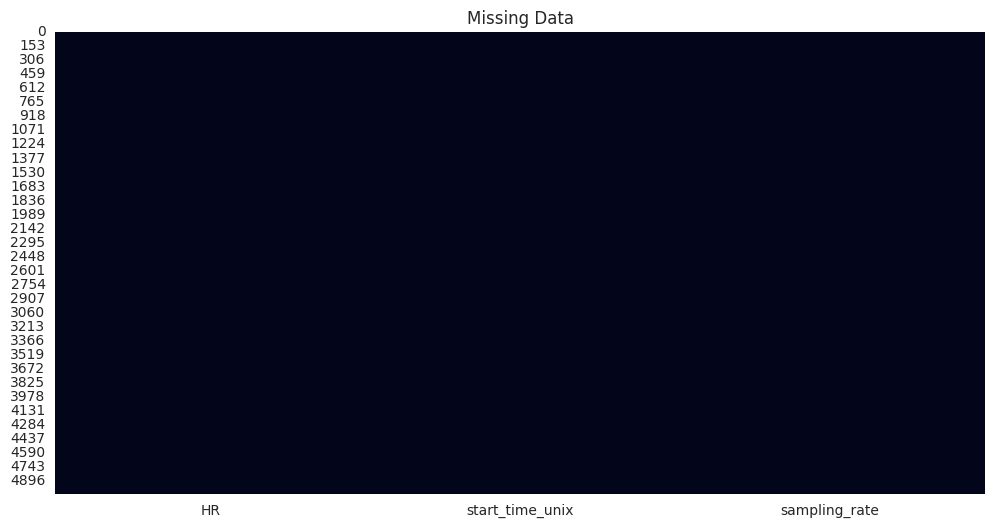

In [63]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data")
plt.show()

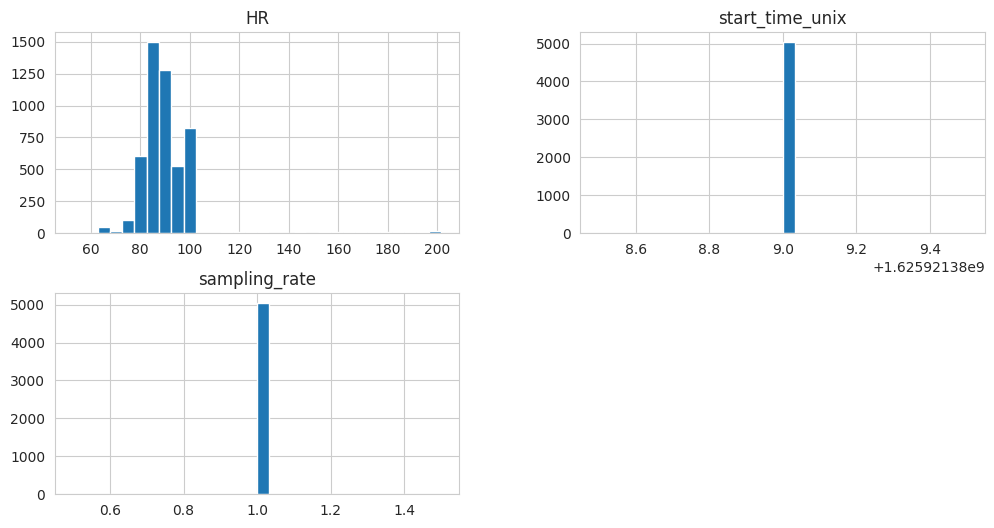

In [64]:
df.hist(bins=30)
plt.show()

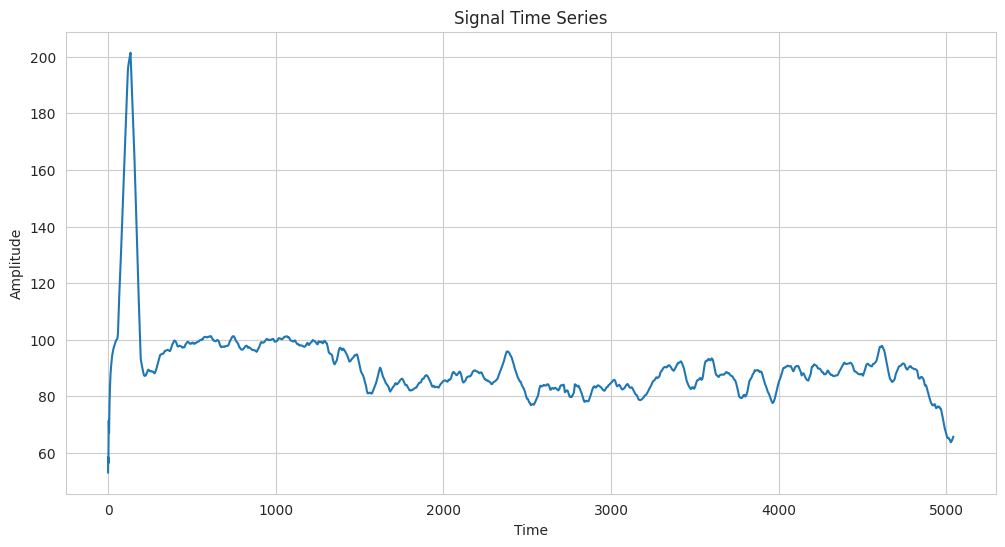

In [65]:
plt.plot(df[df.columns[0]])
plt.title("Signal Time Series")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

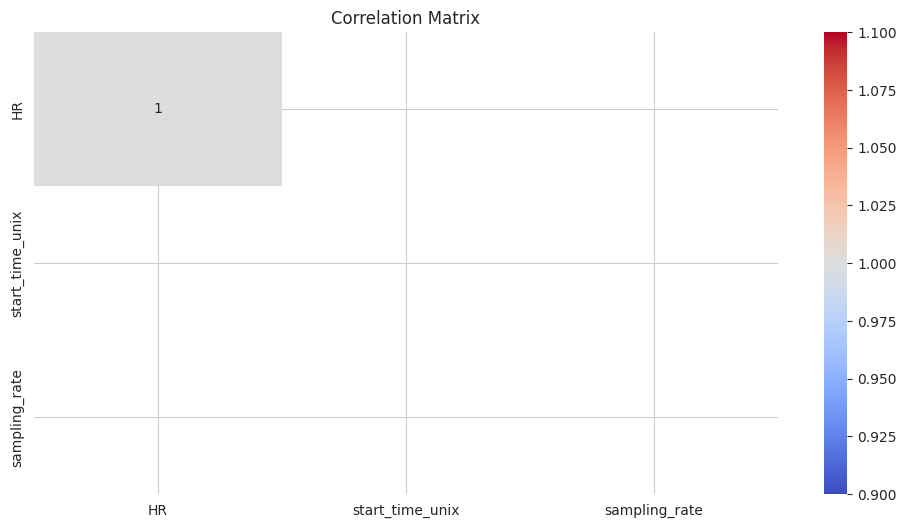

In [66]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.title("Correlation Matrix")
plt.show()

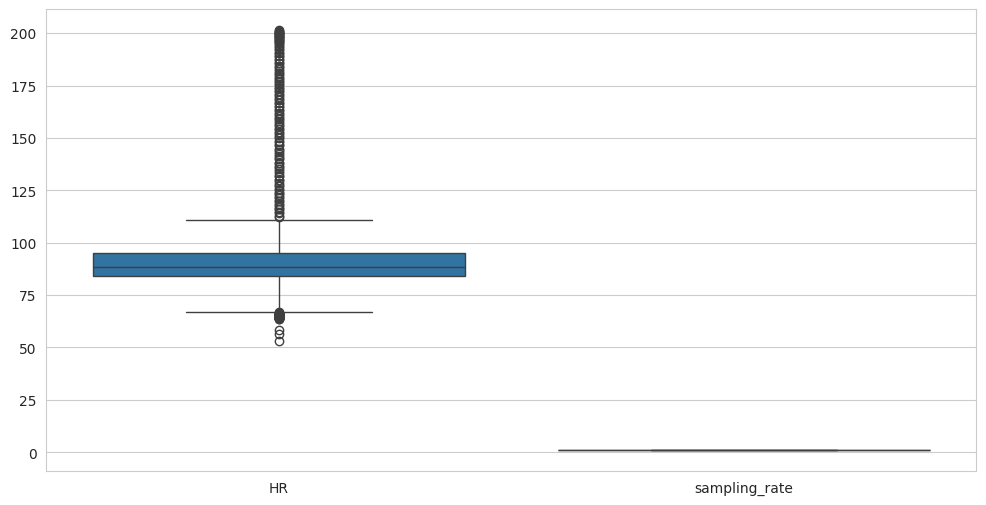

In [67]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols = [c for c in numeric_cols if "time" not in c]

sns.boxplot(data=df[numeric_cols])
plt.show()

In [68]:
sampling_rate = 4

duration_seconds = len(df) / sampling_rate

duration_minutes = duration_seconds / 60

duration_minutes

21.016666666666666

In [69]:
event_files = []

for f in csv_files:
    if "tags" in f.lower():
        event_files.append(f)

event_files

['/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_7/Left_tags.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_7/Right_tags.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_7/tags.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_9/Left_tags.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_9/Right_tags.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/Excluded_ID_9/tags.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/A6/Left_tags.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/A6/Right_tags.csv',
 '/kaggle/working/physionet.org/files/brain-wearable-monitoring/1.0.0/Experiment_1/A6/tags.csv',
 '/kaggle/working/physionet.

In [70]:
events = pd.read_csv(event_files[0])

events.head()

,1625921664.75
0,1.625923e+09
1,1.625923e+09
2,1.625924e+09
3,1.625924e+09
4,1.625925e+09


In [71]:
subjects = set()
sessions = 0
signals = set()
files_list = []

experiments = [d for d in os.listdir(base_path) if "Experiment" in d]

for exp in experiments:
    
    exp_path = os.path.join(base_path, exp)
    
    for subj in os.listdir(exp_path):
        
        subj_path = os.path.join(exp_path, subj)
        
        if os.path.isdir(subj_path) and not subj.startswith("Excluded"):
            
            subjects.add(subj)
            sessions += 1
            
            for f in os.listdir(subj_path):
                
                filepath = os.path.join(subj_path, f)
                files_list.append(filepath)
                
                if f.endswith(".csv"):
                    signals.add(f.split(".")[0])

metadata = {
    "participants": len(subjects),
    "sessions": sessions,
    "total_files": len(files_list),
    "signal_types": list(signals)
}

metadata

{'participants': 20,
 'sessions': 20,
 'total_files': 360,
 'signal_types': ['Right_BVP',
  'EEG_recording',
  'Left_BVP',
  'Left_TEMP',
  'Right_ACC',
  'Right_EDA',
  'Left_ACC',
  'Right_tags',
  'Left_EDA',
  'Left_IBI',
  'Left_HR',
  'Right_IBI',
  'Right_HR',
  'Right_TEMP',
  'tags',
  'Left_tags',
  'n_back_responses']}

In [72]:
summary_table = pd.DataFrame({

"Parameter":[
"Number of Participants",
"Number of Experiments",
"Number of Sessions",
"Signal Types",
"Sampling Frequency",
"Event Markers",
"Recording Duration"
],

"Details":[
metadata["participants"],
2,
metadata["sessions"],
metadata["signal_types"],
"EDA 4Hz, BVP 64Hz, TEMP 4Hz, ACC 32Hz, EEG ~256Hz",
"Stimulus start, task start, participant response",
str(round(duration_minutes,2)) + " minutes"
]

})

summary_table

,Parameter,Details
0,Number of Participants,20
1,Number of Experiments,2
2,Number of Sessions,20
3,Signal Types,"[Right_BVP, EEG_recording, Left_BVP, Left_TEMP..."
4,Sampling Frequency,"EDA 4Hz, BVP 64Hz, TEMP 4Hz, ACC 32Hz, EEG ~256Hz"
5,Event Markers,"Stimulus start, task start, participant response"
6,Recording Duration,21.02 minutes


In [73]:
summary_table.to_csv("dataset_summary.csv", index=False)